<a href="https://colab.research.google.com/github/vlotran/HW2-Excellent-Bigframes-PyTorch/blob/main/notebooks/task1_bigframes_embeddings_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — BigQuery Bigframes → BigQuery Text Embeddings → PyTorch Classification
What this notebook does:

* Loads CFPB complaint narratives directly from BigQuery using
Bigframes.
* Uses BigQuery’s text embedding model (text-embedding-005) to convert each complaint into a numeric vector.
* Trains a PyTorch neural network to predict the complaint’s product category from the embedding.
* Reports evaluation results (accuracy, F1, confusion matrix).

## BigQuery source table:

* bigquery-public-data.cfpb_complaints.complaint_database

# 0. Setup (Auth + Project + Installs)

In [24]:
from google.colab import auth
auth.authenticate_user()

PROJECT_ID = "hw2-excellent"
REGION = "US"
!gcloud config set project {PROJECT_ID}

!pip -q install bigframes torch scikit-learn matplotlib seaborn

import bigframes.pandas as bf
bf.options.bigquery.project = PROJECT_ID
bf.options.bigquery.location = REGION

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


# 1. Load labeled text data from BigQuery with Bigframes

In [27]:
# We will classify complaint narratives into top-K "product" labels.
K = 8
N_PER_CLASS = 400  # samples per class

# (1) Find top-K products with enough text
top_products = bf.read_gbq(f"""
WITH base AS (
  SELECT product, consumer_complaint_narrative AS text
  FROM `bigquery-public-data.cfpb_complaints.complaint_database`
  WHERE consumer_complaint_narrative IS NOT NULL
    AND product IS NOT NULL
)
SELECT product, COUNT(*) AS n
FROM base
GROUP BY product
HAVING n >= {N_PER_CLASS}
ORDER BY n DESC
LIMIT {K}
""").to_pandas()

top_products

,product,n
0,"Credit reporting, credit repair services, or o...",608668
1,Debt collection,201663
2,Mortgage,102390
3,Credit card or prepaid card,90188
4,Checking or savings account,63316
5,Student loan,34364
6,Credit reporting,31587
7,"Money transfer, virtual currency, or money ser...",29319


## 1.1 Build a balanced dataset

In [28]:
import json

products = top_products["product"].tolist()
products_sql = ", ".join(json.dumps(p) for p in products)

df = bf.read_gbq(f"""
WITH base AS (
  SELECT
    product,
    consumer_complaint_narrative AS text
  FROM `bigquery-public-data.cfpb_complaints.complaint_database`
  WHERE consumer_complaint_narrative IS NOT NULL
    AND product IN ({products_sql})
),
sampled AS (
  SELECT * FROM base
  QUALIFY ROW_NUMBER() OVER (PARTITION BY product ORDER BY RAND()) <= {N_PER_CLASS}
)
SELECT * FROM sampled
""")

df.head().to_pandas()

,product,text
0,Checking or savings account,"I have "" opted out '' of all overdraft options..."
1,Debt collection,After pulling credit I instantly disputed the ...
2,"Money transfer, virtual currency, or money ser...",On XXXX I purchased options contracts for XXXX...
3,Checking or savings account,My bank Sun Trust called me on the XX/XX/2020 ...
4,Mortgage,Wells Fargo Mortgage XXXX. XXXX XXXX XXXX XXXX...


# 2. Generate text embeddings in BigQuery

In [29]:
from bigframes.ml.llm import TextEmbeddingGenerator

embedder = TextEmbeddingGenerator(model_name="text-embedding-005")

# predict() returns a Bigframes DF containing:
# - ml_generate_embedding_result (vector)
# - content (original text)
emb_df = embedder.predict(df[["text"]])

emb_df.head().to_pandas()

/usr/local/lib/python3.12/dist-packages/bigframes/session/__init__.py:389: FutureWarning: You are using the BigFrames session default connection: bigframes-
default-connection,             which can be different from the
BigQuery project default connection.             This default
connection may change in the future.
  warnings.warn(msg, category=FutureWarning)


,ml_generate_embedding_result,ml_generate_embedding_statistics,ml_generate_embedding_status,content
0,[-1.11429123e-02 -3.47443148e-02 -3.67448665e-...,"{""token_count"":603,""truncated"":false}",,"I have "" opted out '' of all overdraft options..."
1,[-3.78156304e-02 3.50951366e-02 -2.78720725e-...,"{""token_count"":29,""truncated"":false}",,After pulling credit I instantly disputed the ...
2,[-6.96142316e-02 7.35522481e-03 -3.64587121e-...,"{""token_count"":235,""truncated"":false}",,On XXXX I purchased options contracts for XXXX...
3,[-5.80945760e-02 7.98501365e-04 -7.51459002e-...,"{""token_count"":318,""truncated"":false}",,My bank Sun Trust called me on the XX/XX/2020 ...
4,[-4.41156812e-02 1.11845052e-02 -2.72509102e-...,"{""token_count"":356,""truncated"":false}",,Wells Fargo Mortgage XXXX. XXXX XXXX XXXX XXXX...


## 2.1 Prepare training arrays locally

In [30]:
import numpy as np
import pandas as pd

# Join embeddings with labels
joined = df.join(emb_df)

pdf = joined.to_pandas()
pdf = pdf.dropna(subset=["ml_generate_embedding_result", "product", "text"]).reset_index(drop=True)

# Convert embedding list -> numpy matrix
X = np.vstack(pdf["ml_generate_embedding_result"].apply(np.array).to_numpy()).astype(np.float32)

# Label encode products
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(pdf["product"].values)

print("X shape:", X.shape, "num classes:", len(le.classes_))
pd.Series(pdf["product"]).value_counts()

X shape: (3200, 768) num classes: 8


,count
product,
Checking or savings account,400
Debt collection,400
"Money transfer, virtual currency, or money service",400
Mortgage,400
Credit card or prepaid card,400
"Credit reporting, credit repair services, or other personal consumer reports",400
Credit reporting,400
Student loan,400


# 3. Train PyTorch neural network

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class EmbDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(EmbDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(EmbDataset(X_test, y_test), batch_size=256, shuffle=False)

D = X.shape[1]
C = len(le.classes_)

model = nn.Sequential(
    nn.Linear(D, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, C)
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def eval_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total

for epoch in range(1, 6):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
    acc = eval_accuracy(test_loader)
    print(f"epoch {epoch} test_acc={acc:.4f}")

epoch 1 test_acc=0.7031
epoch 2 test_acc=0.7750
epoch 3 test_acc=0.7719
epoch 4 test_acc=0.7750
epoch 5 test_acc=0.8016


# 4. Evaluation / Results

                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.77      0.90      0.83        80
                                                 Credit card or prepaid card       0.83      0.78      0.80        80
                                                            Credit reporting       0.70      0.69      0.69        80
Credit reporting, credit repair services, or other personal consumer reports       0.67      0.47      0.55        80
                                                             Debt collection       0.68      0.84      0.75        80
                          Money transfer, virtual currency, or money service       0.90      0.82      0.86        80
                                                                    Mortgage       0.90      0.97      0.93        80
                                                       

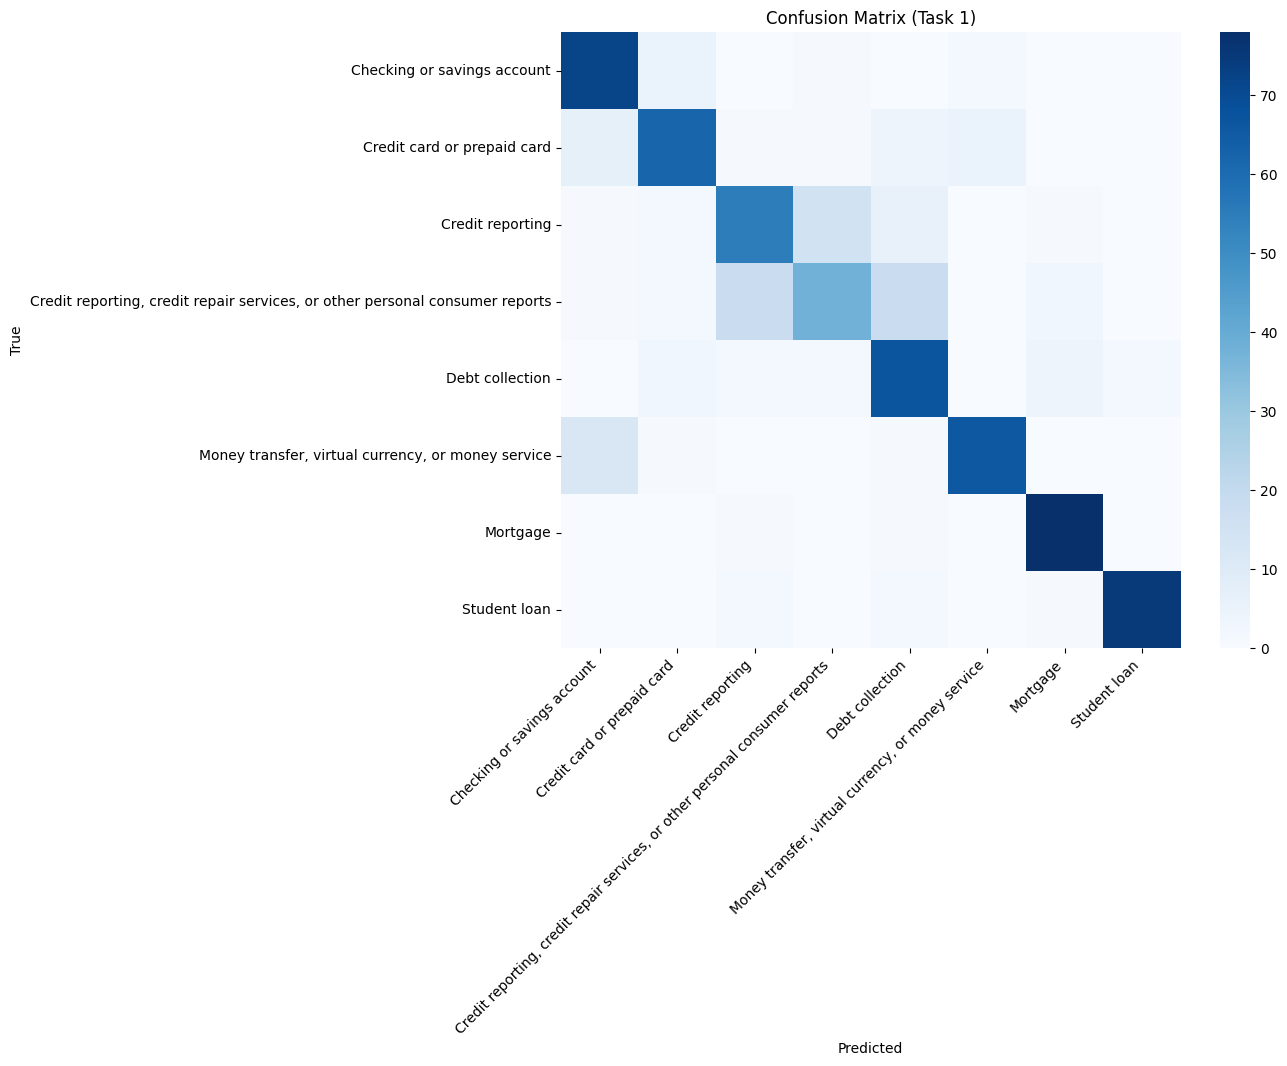

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb).cpu()
        all_preds.append(logits.argmax(dim=1).numpy())
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Task 1)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()